In [1]:
###testing R in jyupter 

In [2]:
library(purrr)
library(tidyverse)
library(edgeR)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.6     ✔ dplyr   1.0.9
✔ tibble  3.1.7     ✔ stringr 1.4.0
✔ tidyr   1.2.0     ✔ forcats 0.5.1
✔ readr   2.1.2     

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Loading required package: limma



In [3]:
lfbl=function(pattern,level=1){
    if(!exists("lof")) lof=vector("character",0)
    temp=list.files(pattern=pattern,no..=T)
    if(!is.na(temp[1])) lof=c(lof,paste0(getwd(),"/",temp))
    if(level>0){
        dirf=list.dirs(full.names=F,recursive=F)
        for(i in dirf){
            setwd(i)
            lof=c(lof,lfbl(pattern,level-1))
            setwd("..")
        }
    }
    return(lof)
}




In [4]:
setwd("/lustre/scratch123/hgi/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome")
getwd()

[1] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome"

In [5]:
f_files = lfbl(pattern = 'featureCounts$',level=2)
f_files


[1] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.1.featureCounts"
  [2] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.2.featureCounts"
  [3] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.3.featureCounts"
  [4] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.1.featureCounts"
  [5] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.2.featureCounts"
  [6] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.3.featureCounts"
  [7] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.1.featureCounts"
  [8] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.2.featureCounts"
  [9] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.3.featureCounts"
 [10] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/A_J/A_J/A_J-12.5dpp.1.featureCounts"                        
 [11] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/A_J/A_J/A_J-12.5dpp.2.featureCounts"                        
 [12] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/A_J/A_J/A_J-12.5dpp.3.featureCounts"                        
 [13] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/A_J/A_J/A_J-16.5dpc.1.featureCounts"                        
 [14] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/A_J/A_J/A_J-16.5dpc.2.featureCounts"                        
 [15] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/A_J/A_J/A_J-16.5dpc.3.featureCounts"                        
 [16] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/A_J/A_J/A_J-20.5dpp.1.featureCounts"                        
 [17] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/A_J/A_J/A_J-20.5dpp.2.featureCounts"                        
 [18] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/A_J/A_J/A_J-20.5dpp.3.featureCounts"                        
 [19] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/AKR_J/AKR_J/AKR_J-12.5dpp.1.featureCounts"                  
 [20] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/AKR_J/AKR_J/AKR_J-12.5dpp.2.featureCounts"                  
 [21] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/AKR_J/AKR_J/AKR_J-12.5dpp.3.featureCounts"                  
 [22] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/tr

In [6]:

groups = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
groups

[1] "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp"
  [4] "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc"
  [7] "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp"
 [10] "A_J-12.5dpp"         "A_J-12.5dpp"         "A_J-12.5dpp"        
 [13] "A_J-16.5dpc"         "A_J-16.5dpc"         "A_J-16.5dpc"        
 [16] "A_J-20.5dpp"         "A_J-20.5dpp"         "A_J-20.5dpp"        
 [19] "AKR_J-12.5dpp"       "AKR_J-12.5dpp"       "AKR_J-12.5dpp"      
 [22] "AKR_J-16.5dpc"       "AKR_J-16.5dpc"       "AKR_J-16.5dpc"      
 [25] "AKR_J-20.5dpp"       "AKR_J-20.5dpp"       "AKR_J-20.5dpp"      
 [28] "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"    
 [31] "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"    
 [34] "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"    
 [37] "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"    
 [40] "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"    
 [43] "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"    
 [46] "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"  
 [49] "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"  
 [52] "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"  
 [55] "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"   
 [58] "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"   
 [61] "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"   
 [64] "CBA_J-12.5dpp"       "CBA_J-12.5dpp"       "CBA_J-12.5dpp"      
 [67] "CBA_J-16.5dpc"       "CBA_J-16.5dpc"       "CBA_J-16.5dpc"      
 [70] "CBA_J-20.5dpp"       "CBA_J-20.5dpp"       "CBA_J-20.5dpp"      
 [73] "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"     
 [76] "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"     
 [79] "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"     
 [82] "FVB_NJ-12.5dpp"      "FVB_NJ-12.5dpp"      "FVB_NJ-12.5dpp"     
 [85] "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"     
 [88] "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"     
 [91] "LP_J-12.5dpp"        "LP_J-12.5dpp"        "LP_J-12.5dpp"       
 [94] "LP_J-16.5dpc"        "LP_J-16.5dpc"        "LP_J-16.5dpc"       
 [97] "LP_J-20.5dpp"        "LP_J-20.5dpp"        "LP_J-20.5dpp"       
[100] "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp" 
[103] "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc" 
[106] "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp" 
[109] "NZO_HlLtJ-12.5dpp"   "NZO_HlLtJ-12.5dpp"   "NZO_HlLtJ-12.5dpp"  
[112] "NZO_HlLtJ-16.5dpc"   "NZO_HlLtJ-16.5dpc"   "NZO_HlLtJ-16.5dpc"  
[115] "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"  
[118] "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"    
[121] "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"    
[124] "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"    
[127] "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"  
[130] "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"  
[133] "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"  
[136] "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"    
[139] "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"    
[142] "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"

In [7]:

#list of sample names with replicates 
lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))

lables

[1] "129S1_SvImJ-12.5dpp.1" "129S1_SvImJ-12.5dpp.2" "129S1_SvImJ-12.5dpp.3"
  [4] "129S1_SvImJ-16.5dpc.1" "129S1_SvImJ-16.5dpc.2" "129S1_SvImJ-16.5dpc.3"
  [7] "129S1_SvImJ-20.5dpp.1" "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3"
 [10] "A_J-12.5dpp.1"         "A_J-12.5dpp.2"         "A_J-12.5dpp.3"        
 [13] "A_J-16.5dpc.1"         "A_J-16.5dpc.2"         "A_J-16.5dpc.3"        
 [16] "A_J-20.5dpp.1"         "A_J-20.5dpp.2"         "A_J-20.5dpp.3"        
 [19] "AKR_J-12.5dpp.1"       "AKR_J-12.5dpp.2"       "AKR_J-12.5dpp.3"      
 [22] "AKR_J-16.5dpc.1"       "AKR_J-16.5dpc.2"       "AKR_J-16.5dpc.3"      
 [25] "AKR_J-20.5dpp.1"       "AKR_J-20.5dpp.2"       "AKR_J-20.5dpp.3"      
 [28] "BALB_cJ-12.5dpp.1"     "BALB_cJ-12.5dpp.2"     "BALB_cJ-12.5dpp.3"    
 [31] "BALB_cJ-16.5dpc.1"     "BALB_cJ-16.5dpc.2"     "BALB_cJ-16.5dpc.3"    
 [34] "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"     "BALB_cJ-20.5dpp.3"    
 [37] "C3H_HeJ-12.5dpp.1"     "C3H_HeJ-12.5dpp.2"     "C3H_HeJ-12.5dpp.3"    
 [40] "C3H_HeJ-16.5dpc.1"     "C3H_HeJ-16.5dpc.2"     "C3H_HeJ-16.5dpc.3"    
 [43] "C3H_HeJ-20.5dpp.1"     "C3H_HeJ-20.5dpp.2"     "C3H_HeJ-20.5dpp.3"    
 [46] "C57BL_6NJ-12.5dpp.1"   "C57BL_6NJ-12.5dpp.2"   "C57BL_6NJ-12.5dpp.3"  
 [49] "C57BL_6NJ-16.5dpc.1"   "C57BL_6NJ-16.5dpc.2"   "C57BL_6NJ-16.5dpc.3"  
 [52] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
 [55] "CAST_EiJ-12.5dpp.1"    "CAST_EiJ-12.5dpp.2"    "CAST_EiJ-12.5dpp.3"   
 [58] "CAST_EiJ-16.5dpc.1"    "CAST_EiJ-16.5dpc.2"    "CAST_EiJ-16.5dpc.3"   
 [61] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
 [64] "CBA_J-12.5dpp.1"       "CBA_J-12.5dpp.2"       "CBA_J-12.5dpp.3"      
 [67] "CBA_J-16.5dpc.1"       "CBA_J-16.5dpc.2"       "CBA_J-16.5dpc.3"      
 [70] "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.2"       "CBA_J-20.5dpp.3"      
 [73] "DBA_2J-12.5dpp.1"      "DBA_2J-12.5dpp.2"      "DBA_2J-12.5dpp.3"     
 [76] "DBA_2J-16.5dpc.1"      "DBA_2J-16.5dpc.2"      "DBA_2J-16.5dpc.3"     
 [79] "DBA_2J-20.5dpp.1"      "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"     
 [82] "FVB_NJ-12.5dpp.1"      "FVB_NJ-12.5dpp.2"      "FVB_NJ-12.5dpp.3"     
 [85] "FVB_NJ-16.5dpc.1"      "FVB_NJ-16.5dpc.2"      "FVB_NJ-16.5dpc.3"     
 [88] "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"      "FVB_NJ-20.5dpp.3"     
 [91] "LP_J-12.5dpp.1"        "LP_J-12.5dpp.2"        "LP_J-12.5dpp.3"       
 [94] "LP_J-16.5dpc.1"        "LP_J-16.5dpc.2"        "LP_J-16.5dpc.3"       
 [97] "LP_J-20.5dpp.1"        "LP_J-20.5dpp.2"        "LP_J-20.5dpp.3"       
[100] "NOD_ShiLtJ-12.5dpp.1"  "NOD_ShiLtJ-12.5dpp.2"  "NOD_ShiLtJ-12.5dpp.3" 
[103] "NOD_ShiLtJ-16.5dpc.1"  "NOD_ShiLtJ-16.5dpc.2"  "NOD_ShiLtJ-16.5dpc.3" 
[106] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.2"  "NOD_ShiLtJ-20.5dpp.3" 
[109] "NZO_HlLtJ-12.5dpp.1"   "NZO_HlLtJ-12.5dpp.2"   "NZO_HlLtJ-12.5dpp.3"  
[112] "NZO_HlLtJ-16.5dpc.1"   "NZO_HlLtJ-16.5dpc.2"   "NZO_HlLtJ-16.5dpc.3"  
[115] "NZO_HlLtJ-20.5dpp.1"   "NZO_HlLtJ-20.5dpp.2"   "NZO_HlLtJ-20.5dpp.3"  
[118] "PWK_PhJ-12.5dpp.1"     "PWK_PhJ-12.5dpp.2"     "PWK_PhJ-12.5dpp.3"    
[121] "PWK_PhJ-16.5dpc.1"     "PWK_PhJ-16.5dpc.2"     "PWK_PhJ-16.5dpc.3"    
[124] "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"     "PWK_PhJ-20.5dpp.3"    
[127] "SPRET_EiJ-12.5dpp.1"   "SPRET_EiJ-12.5dpp.2"   "SPRET_EiJ-12.5dpp.3"  
[130] "SPRET_EiJ-16.5dpc.1"   "SPRET_EiJ-16.5dpc.2"   "SPRET_EiJ-16.5dpc.3"  
[133] "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"   "SPRET_EiJ-20.5dpp.3"  
[136] "WSB_EiJ-12.5dpp.1"     "WSB_EiJ-12.5dpp.2"     "WSB_EiJ-12.5dpp.3"    
[139] "WSB_EiJ-16.5dpc.1"     "WSB_EiJ-16.5dpc.2"     "WSB_EiJ-16.5dpc.3"    
[142] "WSB_EiJ-20.5dpp.1"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

In [8]:
	
df = readDGE(f_files, path=NULL, columns=c(1,7), group= groups, labels = lables,sep="\t" ,skip = 1)

In [9]:
head(df)

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-12.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.1.featureCounts,129S1_SvImJ-12.5dpp,5415711,1
129S1_SvImJ-12.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.2.featureCounts,129S1_SvImJ-12.5dpp,8219093,1
129S1_SvImJ-12.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.3.featureCounts,129S1_SvImJ-12.5dpp,5165055,1
129S1_SvImJ-16.5dpc.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.1.featureCounts,129S1_SvImJ-16.5dpc,2389920,1
129S1_SvImJ-16.5dpc.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.2.featureCounts,129S1_SvImJ-16.5dpc,2272682,1
129S1_SvImJ-16.5dpc.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.3.featureCounts,129S1_SvImJ-16.5dpc,2578167,1
129S1_SvImJ-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.1.featureCounts,129S1_SvImJ-20.5dpp,1924971,1
129S1_SvImJ-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.2.featureCounts,129S1_SvImJ-20.5dpp,1890029,1
129S1_SvImJ-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.3.featureCounts,129S1_SvImJ-20.5dpp,1862577,1


In [10]:
df$counts

,129S1_SvImJ-12.5dpp.1,129S1_SvImJ-12.5dpp.2,129S1_SvImJ-12.5dpp.3,129S1_SvImJ-16.5dpc.1,129S1_SvImJ-16.5dpc.2,129S1_SvImJ-16.5dpc.3,129S1_SvImJ-20.5dpp.1,129S1_SvImJ-20.5dpp.2,129S1_SvImJ-20.5dpp.3,A_J-12.5dpp.1,⋯,SPRET_EiJ-20.5dpp.3,WSB_EiJ-12.5dpp.1,WSB_EiJ-12.5dpp.2,WSB_EiJ-12.5dpp.3,WSB_EiJ-16.5dpc.1,WSB_EiJ-16.5dpc.2,WSB_EiJ-16.5dpc.3,WSB_EiJ-20.5dpp.1,WSB_EiJ-20.5dpp.2,WSB_EiJ-20.5dpp.3
ENSMUST00000237862,7.71,13.07,9.75,33.78,27.82,35.90,3.14,2.98,3.07,22.46,⋯,26.18,32.44,44.89,35.70,61.60,61.56,61.42,27.61,28.32,19.97
ENSMUST00000042497,7.71,13.07,9.75,34.46,28.20,36.40,3.14,2.98,3.07,22.46,⋯,26.18,32.44,44.89,35.70,63.68,62.96,63.50,27.61,28.47,20.25
ENSMUST00000237129,7.71,13.07,9.75,33.45,27.58,35.74,3.14,2.98,3.07,22.46,⋯,26.18,32.44,44.89,35.70,61.46,61.26,61.06,27.56,28.16,19.91
ENSMUST00000128787,7.71,13.07,9.75,33.55,27.67,35.81,3.14,2.98,3.07,22.46,⋯,26.18,32.44,44.89,35.70,61.39,61.45,61.06,27.61,28.24,19.99
ENSMUST00000150852,7.71,13.07,9.75,34.08,28.14,36.15,3.14,2.98,3.07,22.46,⋯,26.18,32.44,44.89,35.70,62.43,61.96,62.09,27.61,28.37,20.05
ENSMUST00000129706,7.67,13.03,9.70,33.18,27.33,35.56,3.14,2.98,3.04,22.44,⋯,26.07,31.94,44.49,35.65,60.97,60.82,60.40,27.21,27.91,19.73
ENSMUST00000136921,6.93,12.08,8.63,28.67,22.94,30.52,2.67,2.64,2.71,20.72,⋯,24.47,28.94,40.58,32.85,52.50,53.39,53.86,24.11,24.76,17.60
ENSMUST00000236203,5.73,10.61,7.17,25.62,21.02,27.64,2.37,2.37,2.48,18.49,⋯,22.31,24.59,35.62,28.25,44.98,44.73,47.35,21.79,22.03,16.08
ENSMUST00000133474,7.71,13.02,9.73,34.08,28.14,36.15,3.14,2.98,3.07,22.46,⋯,26.18,32.44,44.89,35.70,62.42,61.96,62.07,27.61,28.34,19.99
ENSMUST00000149482,3.21,5.74,4.11,9.71,7.97,10.55,0.00,0.00,0.00,10.45,⋯,12.17,12.85,16.26,15.07,22.89,20.31,17.37,7.19,9.44,5.92


In [11]:
df$samples

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-12.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.1.featureCounts,129S1_SvImJ-12.5dpp,5415711,1
129S1_SvImJ-12.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.2.featureCounts,129S1_SvImJ-12.5dpp,8219093,1
129S1_SvImJ-12.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-12.5dpp.3.featureCounts,129S1_SvImJ-12.5dpp,5165055,1
129S1_SvImJ-16.5dpc.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.1.featureCounts,129S1_SvImJ-16.5dpc,2389920,1
129S1_SvImJ-16.5dpc.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.2.featureCounts,129S1_SvImJ-16.5dpc,2272682,1
129S1_SvImJ-16.5dpc.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-16.5dpc.3.featureCounts,129S1_SvImJ-16.5dpc,2578167,1
129S1_SvImJ-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.1.featureCounts,129S1_SvImJ-20.5dpp,1924971,1
129S1_SvImJ-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.2.featureCounts,129S1_SvImJ-20.5dpp,1890029,1
129S1_SvImJ-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/trinity_genome/129S1_SvImJ/129S1_SvImJ/129S1_SvImJ-20.5dpp.3.featureCounts,129S1_SvImJ-20.5dpp,1862577,1


In [12]:
#DESeq and PCA and Dandogram 


library("DESeq2")
library("gplots")
library("RColorBrewer")
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

#save results in this folder 
setwd("/lustre/scratch123/hgi/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/analysis/transcriptCount/trinity_genomes")

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:dplyr’:

    first, rename


The following object is masked from ‘packa

In [13]:
# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)

In [14]:
# First we tell DESeq which samples correspond to which tissues.
samplenames <- tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))

conds = data.frame(samplenames) ##what Desq2 manual calls coldata
colnames(conds)="sample"


In [15]:
# Now we build a DESeq2 Count dataset and normalize it.
mircounts <- df$counts
cds <- DESeqDataSetFromMatrix(countData = round(mircounts), colData = conds, design = ~ sample)
cds <- estimateSizeFactors(cds)
cds <- estimateDispersions(cds)
cds <- nbinomWaldTest(cds)


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substi

In [16]:
#rlog normalisations
rl=vst(cds)


-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.



In [17]:

pdf("BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(mircounts,2,sum)
barplot(prenorm,col=as.factor(samplenames),las=2,names=samplenames,cex.axis = .7, cex.names=.6,beside=TRUE, border="white")

postnorm=apply(counts(cds,normalized=TRUE),2,sum)
barplot(postnorm,col=as.factor(samplenames),las=2,names=samplenames,cex.axis = .7, cex.names=.6,beside=TRUE, border="white")
dev.off()


png 
  2

In [31]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 9) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw() + ggtitle(timePoint) 
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (timePoint in c("12.5","16.5","20.5")) {
print(timePoint)
rl.sub <- rl[ , rl$sample %in%  grep(paste0(timePoint), samplenames, value = TRUE) ]
pdf(paste0("PCA_After_1vs2_Beginning_",timePoint,".pdf"))
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = nrow(counts(cds))))
dev.off()
}


[1] "12.5"
[1] "16.5"
[1] "20.5"


In [30]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw()+  theme(legend.text=element_text(size=5))
  
}

pdf("PCA_After_1vs2_Beginning.pdf",paper="a4")
plotPCA.san(rl, intgroup = "sample", ntop = nrow(counts(cds)))
dev.off()

png 
  2

In [22]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 9) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw() + ggtitle(strain) 
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (strain in strains) {
print(strain)
rl.sub <- rl[ , rl$sample %in%  grep(paste0("^",strain), samplenames, value = TRUE) ]
pdf(paste0("PCA_After_1vs2_Beginning_",strain,".pdf"))
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = nrow(counts(cds))))
dev.off()
}


[1] "129S1_SvImJ"
[1] "A_J"
[1] "AKR_J"
[1] "BALB_cJ"
[1] "C3H_HeJ"
[1] "C57BL_6NJ"
[1] "CAST_EiJ"
[1] "CBA_J"
[1] "DBA_2J"
[1] "FVB_NJ"
[1] "LP_J"
[1] "NOD_ShiLtJ"
[1] "NZO_HlLtJ"
[1] "PWK_PhJ"
[1] "SPRET_EiJ"
[1] "WSB_EiJ"


In [23]:
rl[ , rl$sample %in%  grep("PWK_PhJ", samplenames, value = TRUE) ]

class: DESeqTransform 
dim: 92011 9 
metadata(1): version
assays(1): ''
rownames(92011): ENSMUST00000237862 ENSMUST00000042497 ...
  ENSMUST00000136258 ENSMUST00000218375
rowData names(206): baseMean baseVar ... maxCooks dispFit
colnames(9): PWK_PhJ-12.5dpp.1 PWK_PhJ-12.5dpp.2 ... PWK_PhJ-20.5dpp.2
  PWK_PhJ-20.5dpp.3
colData names(2): sample sizeFactor

In [24]:

##To plot PC2 versus 3
library(genefilter)
library(ggplot2)
library(ggrepel)

plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC2 = pca$x[, 2], PC3 = pca$x[, 3], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[2:3]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC2", y = "PC3", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) + coord_fixed() 
  
}

pdf("PCA_After_3.pdf",paper="a4")
plotPCA.san(rl, intgroup = 'sample', ntop = nrow(counts(cds)))
dev.off()


Attaching package: ‘genefilter’


The following objects are masked from ‘package:MatrixGenerics’:

    rowSds, rowVars


The following objects are masked from ‘package:matrixStats’:

    rowSds, rowVars


The following object is masked from ‘package:readr’:

    spec




png 
  2

In [25]:
##To plot PC1 versus 3
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC3 = pca$x[, 3], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:3]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC3", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) + coord_fixed() 
  
}

pdf("PCA_After_4.pdf",paper="a4")
plotPCA.san(rl, intgroup = 'sample', ntop = nrow(counts(cds)))
dev.off()

png 
  2

In [26]:
####
# Margins area


pdf("InitialHeatMap.pdf",paper="special",width=25000, height=25000,title="Trinity Assemblies",fillOddEven=T)
heatmap.2(cor(mircounts),trace="none",col=hmcol,main="Sample Correlation",cexRow=800,cexCol=800,
    margins=c(9000,9000),na.rm=T,key=T,offsetRow=300,offsetCol=300,keysize=1,density.info='histogram')
dev.off()


png 
  2

In [27]:
##And the Spearman Dendogram
foo_sub_1 = counts(cds, normalized = TRUE)

foo_cor_1 = cor(foo_sub_1, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="dendrogram.pdf", height=100, width=30)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2

[1] "129S1_SvImJ-12.5dpp.1" "129S1_SvImJ-12.5dpp.2" "129S1_SvImJ-12.5dpp.3"
  [4] "129S1_SvImJ-16.5dpc.1" "129S1_SvImJ-16.5dpc.2" "129S1_SvImJ-16.5dpc.3"
  [7] "129S1_SvImJ-20.5dpp.1" "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3"
 [10] "A_J-12.5dpp.1"         "A_J-12.5dpp.2"         "A_J-12.5dpp.3"        
 [13] "A_J-16.5dpc.1"         "A_J-16.5dpc.2"         "A_J-16.5dpc.3"        
 [16] "A_J-20.5dpp.1"         "A_J-20.5dpp.2"         "A_J-20.5dpp.3"        
 [19] "AKR_J-12.5dpp.1"       "AKR_J-12.5dpp.2"       "AKR_J-12.5dpp.3"      
 [22] "AKR_J-16.5dpc.1"       "AKR_J-16.5dpc.2"       "AKR_J-16.5dpc.3"      
 [25] "AKR_J-20.5dpp.1"       "AKR_J-20.5dpp.2"       "AKR_J-20.5dpp.3"      
 [28] "BALB_cJ-12.5dpp.1"     "BALB_cJ-12.5dpp.2"     "BALB_cJ-12.5dpp.3"    
 [31] "BALB_cJ-16.5dpc.1"     "BALB_cJ-16.5dpc.2"     "BALB_cJ-16.5dpc.3"    
 [34] "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"     "BALB_cJ-20.5dpp.3"    
 [37] "C3H_HeJ-12.5dpp.1"     "C3H_HeJ-12.5dpp.2"     "C3H_HeJ-12.5dpp.3"    
 [40] "C3H_HeJ-16.5dpc.1"     "C3H_HeJ-16.5dpc.2"     "C3H_HeJ-16.5dpc.3"    
 [43] "C3H_HeJ-20.5dpp.1"     "C3H_HeJ-20.5dpp.2"     "C3H_HeJ-20.5dpp.3"    
 [46] "C57BL_6NJ-12.5dpp.1"   "C57BL_6NJ-12.5dpp.2"   "C57BL_6NJ-12.5dpp.3"  
 [49] "C57BL_6NJ-16.5dpc.1"   "C57BL_6NJ-16.5dpc.2"   "C57BL_6NJ-16.5dpc.3"  
 [52] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
 [55] "CAST_EiJ-12.5dpp.1"    "CAST_EiJ-12.5dpp.2"    "CAST_EiJ-12.5dpp.3"   
 [58] "CAST_EiJ-16.5dpc.1"    "CAST_EiJ-16.5dpc.2"    "CAST_EiJ-16.5dpc.3"   
 [61] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
 [64] "CBA_J-12.5dpp.1"       "CBA_J-12.5dpp.2"       "CBA_J-12.5dpp.3"      
 [67] "CBA_J-16.5dpc.1"       "CBA_J-16.5dpc.2"       "CBA_J-16.5dpc.3"      
 [70] "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.2"       "CBA_J-20.5dpp.3"      
 [73] "DBA_2J-12.5dpp.1"      "DBA_2J-12.5dpp.2"      "DBA_2J-12.5dpp.3"     
 [76] "DBA_2J-16.5dpc.1"      "DBA_2J-16.5dpc.2"      "DBA_2J-16.5dpc.3"     
 [79] "DBA_2J-20.5dpp.1"      "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"     
 [82] "FVB_NJ-12.5dpp.1"      "FVB_NJ-12.5dpp.2"      "FVB_NJ-12.5dpp.3"     
 [85] "FVB_NJ-16.5dpc.1"      "FVB_NJ-16.5dpc.2"      "FVB_NJ-16.5dpc.3"     
 [88] "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"      "FVB_NJ-20.5dpp.3"     
 [91] "LP_J-12.5dpp.1"        "LP_J-12.5dpp.2"        "LP_J-12.5dpp.3"       
 [94] "LP_J-16.5dpc.1"        "LP_J-16.5dpc.2"        "LP_J-16.5dpc.3"       
 [97] "LP_J-20.5dpp.1"        "LP_J-20.5dpp.2"        "LP_J-20.5dpp.3"       
[100] "NOD_ShiLtJ-12.5dpp.1"  "NOD_ShiLtJ-12.5dpp.2"  "NOD_ShiLtJ-12.5dpp.3" 
[103] "NOD_ShiLtJ-16.5dpc.1"  "NOD_ShiLtJ-16.5dpc.2"  "NOD_ShiLtJ-16.5dpc.3" 
[106] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.2"  "NOD_ShiLtJ-20.5dpp.3" 
[109] "NZO_HlLtJ-12.5dpp.1"   "NZO_HlLtJ-12.5dpp.2"   "NZO_HlLtJ-12.5dpp.3"  
[112] "NZO_HlLtJ-16.5dpc.1"   "NZO_HlLtJ-16.5dpc.2"   "NZO_HlLtJ-16.5dpc.3"  
[115] "NZO_HlLtJ-20.5dpp.1"   "NZO_HlLtJ-20.5dpp.2"   "NZO_HlLtJ-20.5dpp.3"  
[118] "PWK_PhJ-12.5dpp.1"     "PWK_PhJ-12.5dpp.2"     "PWK_PhJ-12.5dpp.3"    
[121] "PWK_PhJ-16.5dpc.1"     "PWK_PhJ-16.5dpc.2"     "PWK_PhJ-16.5dpc.3"    
[124] "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"     "PWK_PhJ-20.5dpp.3"    
[127] "SPRET_EiJ-12.5dpp.1"   "SPRET_EiJ-12.5dpp.2"   "SPRET_EiJ-12.5dpp.3"  
[130] "SPRET_EiJ-16.5dpc.1"   "SPRET_EiJ-16.5dpc.2"   "SPRET_EiJ-16.5dpc.3"  
[133] "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"   "SPRET_EiJ-20.5dpp.3"  
[136] "WSB_EiJ-12.5dpp.1"     "WSB_EiJ-12.5dpp.2"     "WSB_EiJ-12.5dpp.3"    
[139] "WSB_EiJ-16.5dpc.1"     "WSB_EiJ-16.5dpc.2"     "WSB_EiJ-16.5dpc.3"    
[142] "WSB_EiJ-20.5dpp.1"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

,129S1_SvImJ-12.5dpp.1,129S1_SvImJ-12.5dpp.2,129S1_SvImJ-12.5dpp.3
,<dbl>,<dbl>,<dbl>
ENSMUST00000237862,5.268679,5.294686,6.383301
ENSMUST00000042497,5.268679,5.294686,6.383301
ENSMUST00000237129,5.268679,5.294686,6.383301
ENSMUST00000128787,5.268679,5.294686,6.383301
ENSMUST00000150852,5.268679,5.294686,6.383301
ENSMUST00000129706,5.268679,5.294686,6.383301


,129S1_SvImJ-12.5dpp,129S1_SvImJ-16.5dpc,129S1_SvImJ-20.5dpp,A_J-12.5dpp,A_J-16.5dpc,A_J-20.5dpp,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,BALB_cJ-12.5dpp,⋯,NZO_HlLtJ-20.5dpp,PWK_PhJ-12.5dpp,PWK_PhJ-16.5dpc,PWK_PhJ-20.5dpp,SPRET_EiJ-12.5dpp,SPRET_EiJ-16.5dpc,SPRET_EiJ-20.5dpp,WSB_EiJ-12.5dpp,WSB_EiJ-16.5dpc,WSB_EiJ-20.5dpp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUST00000237862,5.648889,42.18992,16.23377,14.5469,87.53941,23.36403,9.365784,168.93512,30.19245,14.71429,⋯,18.67653,7.448822,59.42499,9.404605,26.15792,53.65024,16.18609,10.63225,73.62933,25.69475
ENSMUST00000042497,5.648889,42.18992,16.23377,14.5469,87.53941,23.36403,9.365784,171.12195,30.19245,14.71429,⋯,18.67653,7.448822,59.22430,9.404605,26.49057,53.98943,16.18609,10.63225,76.01896,25.69475
ENSMUST00000237129,5.648889,41.75431,16.23377,14.5469,87.53941,23.36403,9.365784,168.38326,30.19245,14.71429,⋯,18.67653,7.448822,59.22430,9.404605,26.06349,53.52478,16.18609,10.63225,72.84689,25.69475
ENSMUST00000128787,5.648889,42.18992,16.23377,14.5469,86.72872,23.36403,9.365784,167.35081,30.19245,14.71429,⋯,18.67653,7.448822,58.70960,9.404605,26.06349,53.52478,16.18609,10.63225,72.84689,25.69475
ENSMUST00000150852,5.648889,42.18992,16.23377,14.5469,38.21199,23.36403,9.365784,102.59139,30.19245,14.71429,⋯,18.67653,7.448822,27.60578,9.404605,26.15792,53.98943,16.18609,10.63225,74.04110,25.69475
ENSMUST00000129706,5.648889,41.29287,16.23377,14.5469,37.07409,23.36403,9.365784,99.97463,30.19245,14.55880,⋯,18.67653,7.335788,27.16747,9.404605,25.85786,52.97670,16.18609,10.55650,72.43512,25.36474


[1] 92011

[1] 3959

,129S1_SvImJ-12.5dpp,129S1_SvImJ-16.5dpc,129S1_SvImJ-20.5dpp,A_J-12.5dpp,A_J-16.5dpc,A_J-20.5dpp,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,BALB_cJ-12.5dpp,⋯,NZO_HlLtJ-20.5dpp,PWK_PhJ-12.5dpp,PWK_PhJ-16.5dpc,PWK_PhJ-20.5dpp,SPRET_EiJ-12.5dpp,SPRET_EiJ-16.5dpc,SPRET_EiJ-20.5dpp,WSB_EiJ-12.5dpp,WSB_EiJ-16.5dpc,WSB_EiJ-20.5dpp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUST00000027373,18530.3540,1607.229,930.759771,10961.184,4154.62526,4415.2416,7067.0220,2847.54743,138.5277,22168.4055,⋯,4327.1359,13021.8487,3054.58868,1765.90073,11776.2751,10378.471,12625.46696,9344.78501,2957.061188,5512.319249
ENSMUST00000181906,333.8997,0.000,46206.437977,624.649,46.80397,17605.4904,369.9138,28.39212,40552.1468,222.4061,⋯,24296.9417,251.4221,28.70142,10454.47202,289.3512,283.600,35793.70567,25.04879,7.616907,13326.306537
ENSMUST00000061617,3996.8777,2045.211,15955.645820,4112.118,1061.12054,16447.9995,4286.5457,915.74406,18319.9829,5228.8332,⋯,17479.3346,3952.6070,606.66608,4711.15923,5358.7200,2412.779,1859.55018,5843.33938,2735.782140,12880.353769
ENSMUST00000058438,5014.9097,1296.475,4873.399674,6387.026,1771.59350,3477.3813,6150.9687,1443.20866,9772.7702,9057.6270,⋯,13119.8581,9180.7621,1494.15178,6077.14655,13437.2176,5983.340,7028.80075,4682.02429,1775.846264,6130.241754
ENSMUST00000206519,1444.4606,4190.199,5.411255,1830.015,4518.81919,872.3854,3255.6065,7741.54538,1302.2583,1072.8259,⋯,647.5229,335.9552,2480.76819,62.81988,484.9285,8660.987,138.79620,10597.14869,47724.084025,130.288837
ENSMUST00000205274,1368.8722,3151.588,5.411255,1716.279,4403.17204,825.4145,2990.1573,4803.29275,1229.9728,1053.9215,⋯,615.6789,166.7533,1902.45601,34.63217,410.5339,5243.510,75.84197,9945.91531,34943.973563,8.419737


,129S1_SvImJ-12.5dpp,129S1_SvImJ-16.5dpc,129S1_SvImJ-20.5dpp,A_J-12.5dpp,A_J-16.5dpc,A_J-20.5dpp,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,BALB_cJ-12.5dpp,⋯,PWK_PhJ-12.5dpp,PWK_PhJ-16.5dpc,PWK_PhJ-20.5dpp,SPRET_EiJ-12.5dpp,SPRET_EiJ-16.5dpc,SPRET_EiJ-20.5dpp,WSB_EiJ-12.5dpp,WSB_EiJ-16.5dpc,WSB_EiJ-20.5dpp,ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUST00000027373,18530.3540,1607.229,930.759771,10961.184,4154.62526,4415.2416,7067.0220,2847.54743,138.5277,22168.4055,⋯,13021.8487,3054.58868,1765.90073,11776.2751,10378.471,12625.46696,9344.78501,2957.061188,5512.319249,ENSMUST00000027373
ENSMUST00000181906,333.8997,0.000,46206.437977,624.649,46.80397,17605.4904,369.9138,28.39212,40552.1468,222.4061,⋯,251.4221,28.70142,10454.47202,289.3512,283.600,35793.70567,25.04879,7.616907,13326.306537,ENSMUST00000181906
ENSMUST00000061617,3996.8777,2045.211,15955.645820,4112.118,1061.12054,16447.9995,4286.5457,915.74406,18319.9829,5228.8332,⋯,3952.6070,606.66608,4711.15923,5358.7200,2412.779,1859.55018,5843.33938,2735.782140,12880.353769,ENSMUST00000061617
ENSMUST00000058438,5014.9097,1296.475,4873.399674,6387.026,1771.59350,3477.3813,6150.9687,1443.20866,9772.7702,9057.6270,⋯,9180.7621,1494.15178,6077.14655,13437.2176,5983.340,7028.80075,4682.02429,1775.846264,6130.241754,ENSMUST00000058438
ENSMUST00000206519,1444.4606,4190.199,5.411255,1830.015,4518.81919,872.3854,3255.6065,7741.54538,1302.2583,1072.8259,⋯,335.9552,2480.76819,62.81988,484.9285,8660.987,138.79620,10597.14869,47724.084025,130.288837,ENSMUST00000206519
ENSMUST00000205274,1368.8722,3151.588,5.411255,1716.279,4403.17204,825.4145,2990.1573,4803.29275,1229.9728,1053.9215,⋯,166.7533,1902.45601,34.63217,410.5339,5243.510,75.84197,9945.91531,34943.973563,8.419737,ENSMUST00000205274


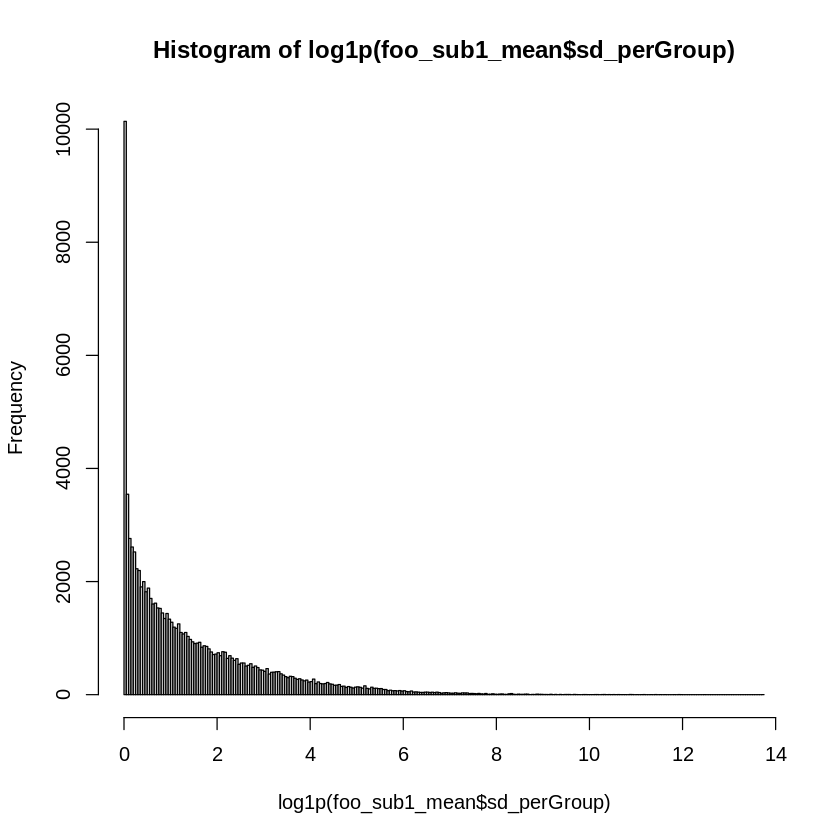

png 
  2

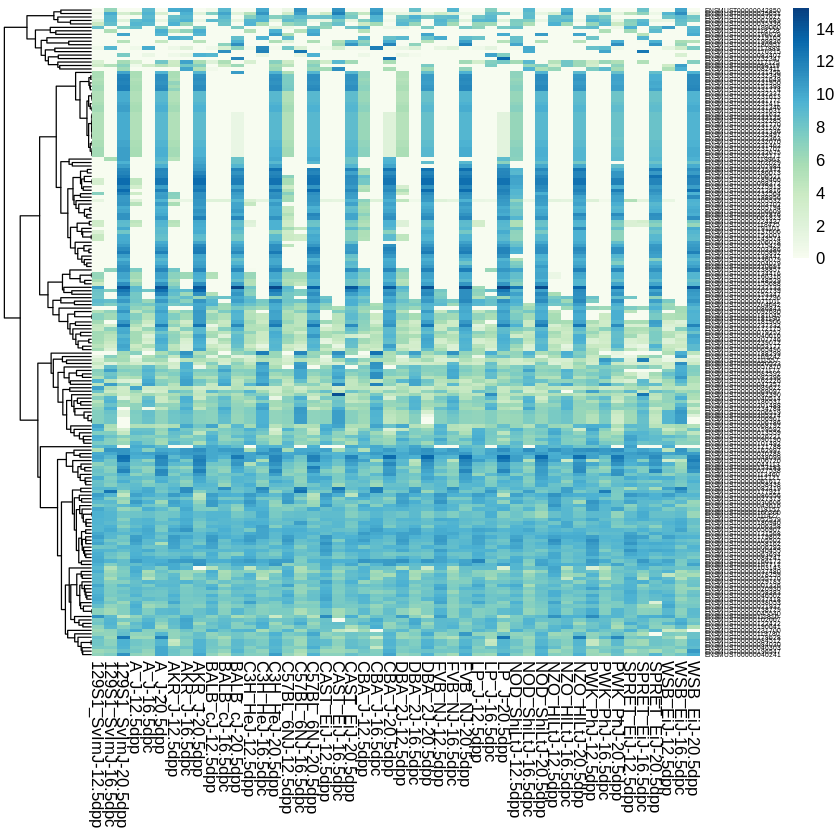

In [28]:

##NEXT IS THE TOP 15% VARIANT miRNA plot on the means. Then the subset more useful miRNA plot
library(pheatmap)

foo_sub_1 <- as.data.frame.matrix(foo_sub_1) #convert from matrix to data frame
## use for eg foo$`hPGC_M_Wk9_n1` <- foo$`hPGC-M-Wk9_2` if only want one biol replicate

colnames(foo_sub_1)

head(foo_sub_1[ , grepl( "^129S1_SvImJ-12.5dpp" , names( foo_sub_1 ) ) ])
foo_sub1_mean = data.frame(matrix(NA, nrow = nrow(foo_sub_1), ncol = 0))
row.names(foo_sub1_mean) <- row.names(foo_sub_1)
for (sample in samplenames) {
foo_sub1_mean[sample] <- apply(foo_sub_1[ , grepl(paste0( "^",sample) , names( foo_sub_1 ) ) ], 1, mean)
}
head(foo_sub1_mean) 

foo_sub1_mean$sd_perGroup <- apply(foo_sub1_mean,1,sd)
hist(log1p(foo_sub1_mean$sd_perGroup),breaks = 200)


nrow(foo_sub1_mean)
3959
foo_sub1_mean_top15sd <- foo_sub1_mean[foo_sub1_mean$sd_perGroup>3959,1:48]
head(foo_sub1_mean_top15sd)
foo_sub1_mean_top15sd$ID<-rownames(foo_sub1_mean_top15sd)
head(foo_sub1_mean_top15sd)



save_pheatmap_pdf <- function(x, filename, width=15, height=25) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    pdf(filename, width=width, height=height,paper="special")
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

savePheatmap <- pheatmap(log1p(foo_sub1_mean_top15sd[,1:48]),width=30000,height=50000, border_color = NA,show_rownames = T, cluster_cols = F, labels_row = foo_sub1_mean_top15sd$ID,cutree_rows = 1,fontsize_row = 4, color = hmcol)
save_pheatmap_pdf(savePheatmap,"InitialPheatMap.pdf")

png 
  2

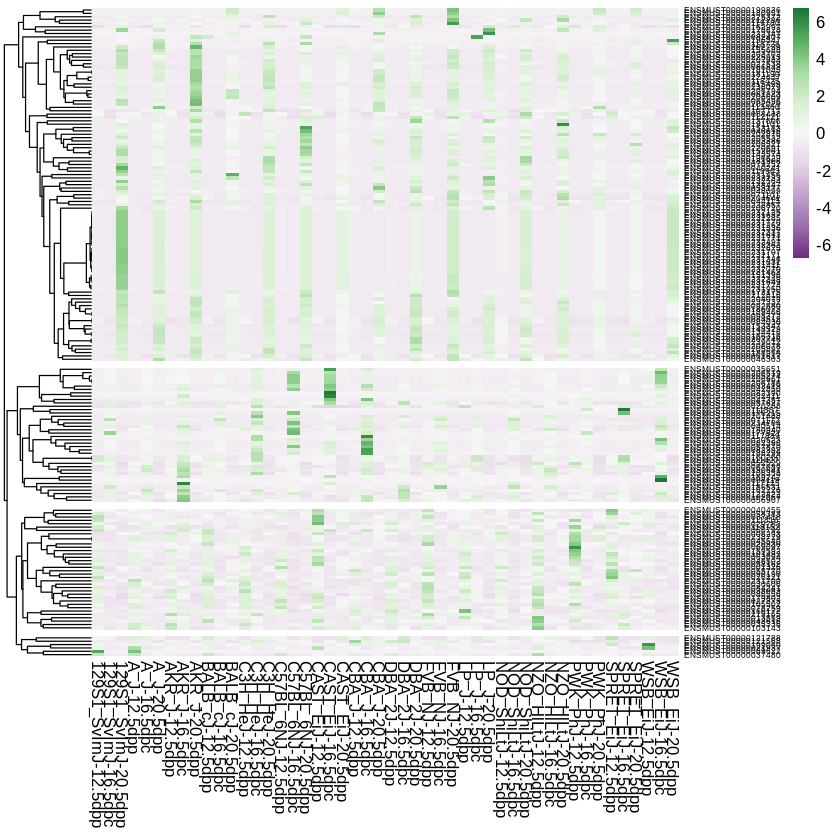

In [29]:
##for z-score
myCol = colorRampPalette(brewer.pal(9,"PRGn"))(100)

savePheatmapZScore <- pheatmap(foo_sub1_mean_top15sd[,1:48], border_color = NA,show_rownames = T,scale = "row",labels_row = foo_sub1_mean_top15sd$ID,cutree_rows = 4,fontsize_row = 5, cluster_cols = F, color = myCol)
save_pheatmap_pdf(savePheatmapZScore,"InitialPheatMap_zScore.pdf")